<a href="https://colab.research.google.com/github/PratikshaShind/OASIS-INFOBYTE/blob/main/PratikshaShinde_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Shape ---
Rows: 1000, Columns: 9

--- Column Data Types ---
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

--- Null Values ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
--- Numerical Summary ---
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.

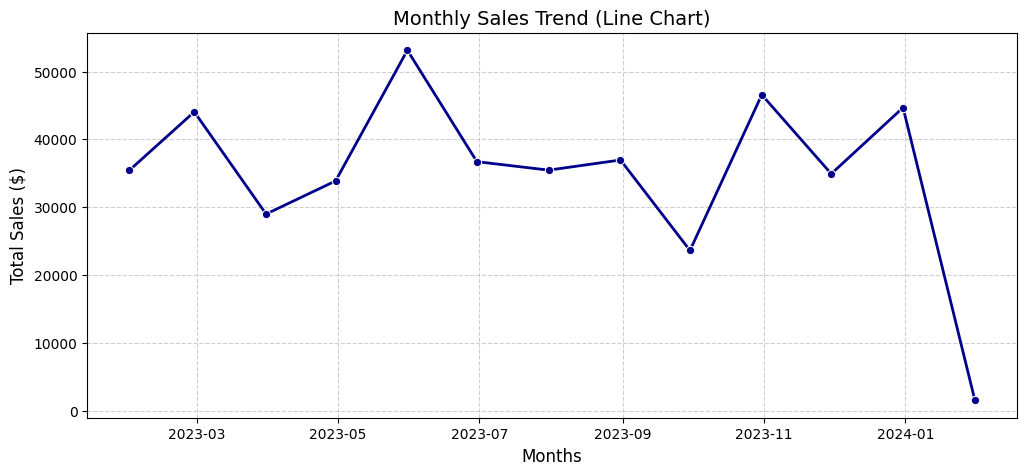

/tmp/ipykernel_1496/3546354443.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age_Group', order=age_labels, palette='pastel')


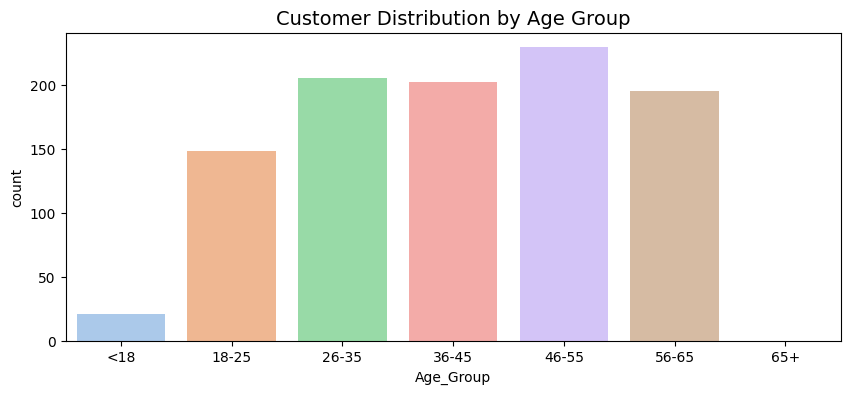

/tmp/ipykernel_1496/3546354443.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='muted')


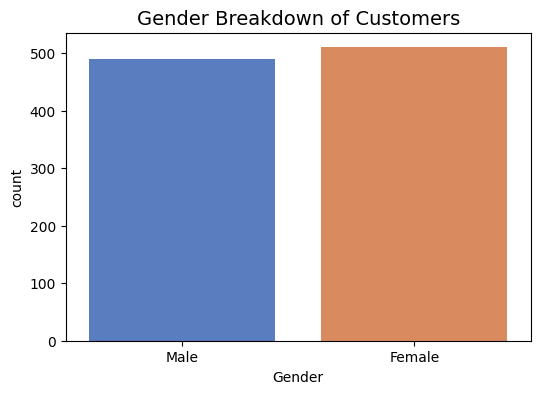

/tmp/ipykernel_1496/3546354443.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_revenue, x='Product Category', y='Total Amount', palette='viridis')


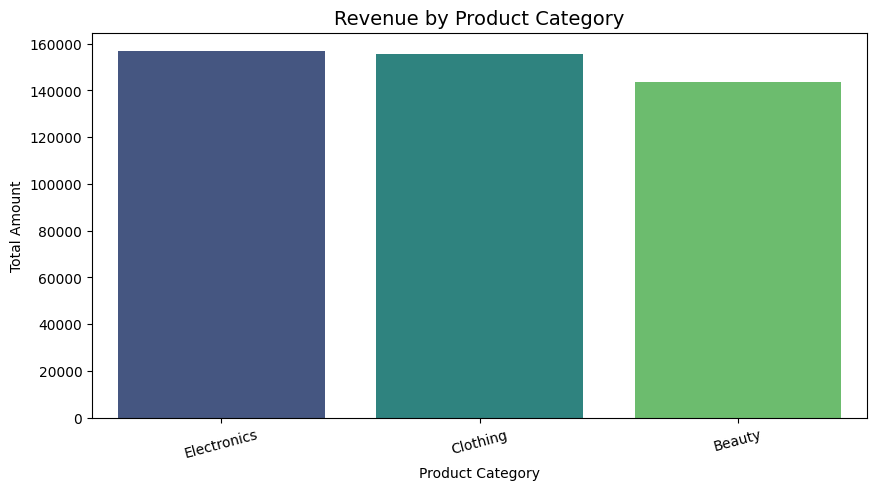

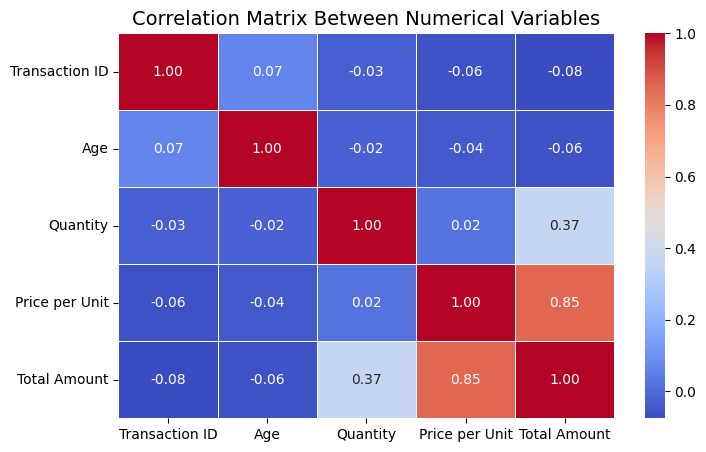

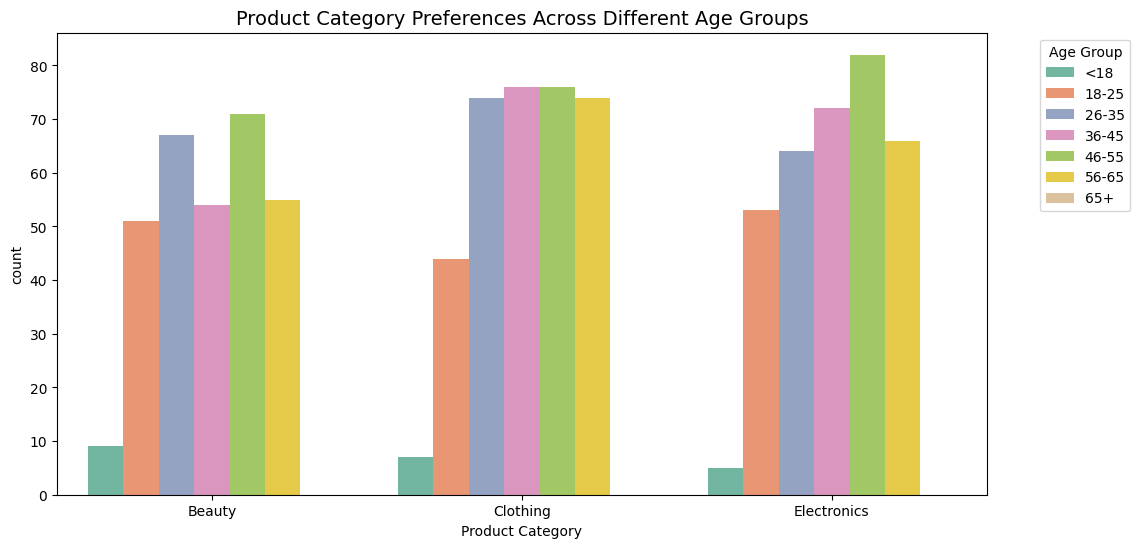

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('retail_sales_dataset.csv')

#  (Shape)
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

#  (Data Types)
print("\n--- Column Data Types ---")
print(df.dtypes)

#  (Null Value Check)
print("\n--- Null Values ---")
print(df.isnull().sum())

#  (Mean, Median, Std Dev)
print("--- Numerical Summary ---")
print(df.describe())

#  (Mode)
print("\n--- Mode for Dataset Columns ---")
print(df.mode().iloc[0])

df['Date'] = pd.to_datetime(df['Date'])

#  (Monthly)
monthly_sales = df.set_index('Date').resample('ME')['Total Amount'].sum()

# Line chart
plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='darkblue', linewidth=2)
plt.title('Monthly Sales Trend (Line Chart)', fontsize=14)
plt.xlabel('Months', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Age_Group', order=age_labels, palette='pastel')
plt.title('Customer Distribution by Age Group', fontsize=14)
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', palette='muted')
plt.title('Gender Breakdown of Customers', fontsize=14)
plt.show()


category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=category_revenue, x='Product Category', y='Total Amount', palette='viridis')
plt.title('Revenue by Product Category', fontsize=14)
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 5))
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Between Numerical Variables', fontsize=14)
plt.show()


plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Product Category', hue='Age_Group', palette='Set2')
plt.title('Product Category Preferences Across Different Age Groups', fontsize=14)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



/tmp/ipykernel_1496/1862196169.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age_Group', order=age_labels, palette='pastel', ax=axes[0])
/tmp/ipykernel_1496/1862196169.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='muted', ax=axes[1])


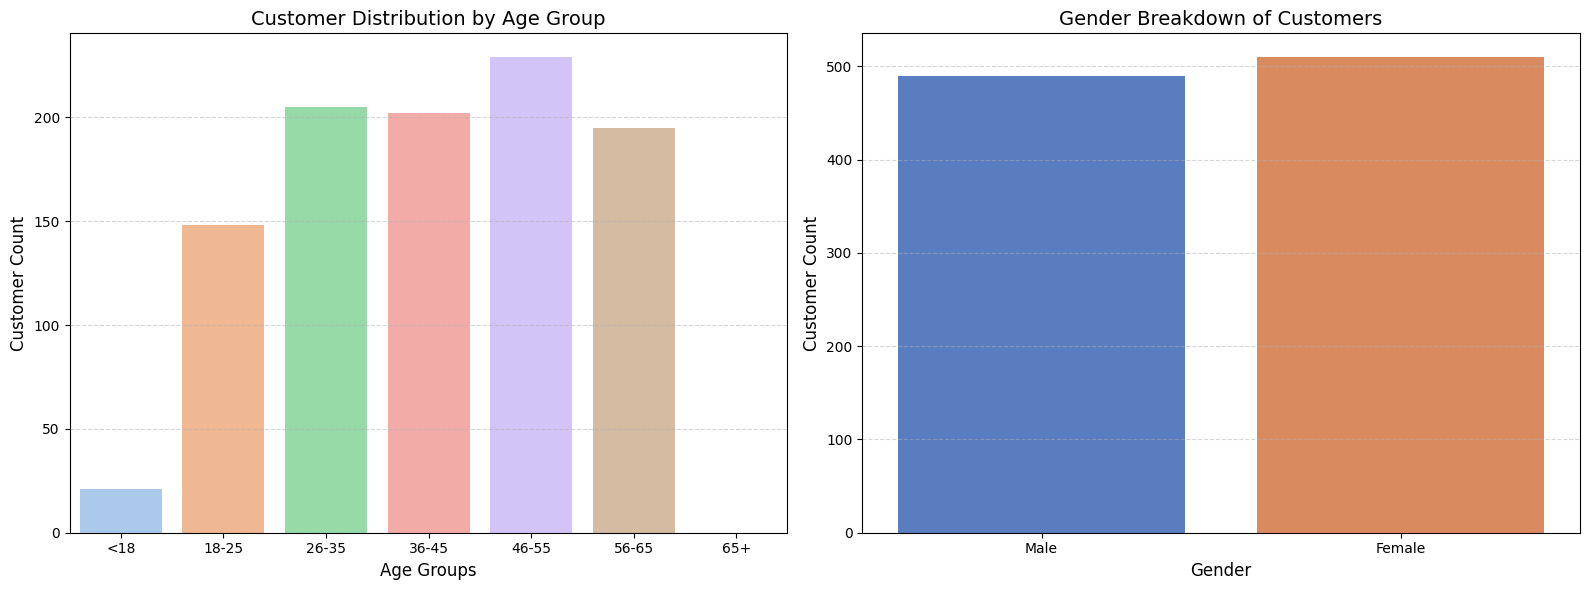

In [7]:
# Customer Demographics Analysis
# In this section, we analyze the distribution of our customer base across different age groups and genders to understand our primary target audience.

# Create age groups (Binning)
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Set up the visualization plot with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Age Group Distribution Chart
sns.countplot(data=df, x='Age_Group', order=age_labels, palette='pastel', ax=axes[0])
axes[0].set_title('Customer Distribution by Age Group', fontsize=14)
axes[0].set_xlabel('Age Groups', fontsize=12)
axes[0].set_ylabel('Customer Count', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. Gender Breakdown Chart
sns.countplot(data=df, x='Gender', palette='muted', ax=axes[1])
axes[1].set_title('Gender Breakdown of Customers', fontsize=14)
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Customer Count', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Display the plots neatly
plt.tight_layout()
plt.show()

**Observations:**
* The age group distribution shows that the majority of our customers fall within the [mention the highest bar group, e.g., 26-35] range.
* The gender breakdown shows a relatively [equal / skewed] distribution between Male and Female shoppers.
